# Swarm MAG data products

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os

import geospacelab.visualization.mpl.dashboards as dashboards

cwd = pathlib.Path(os.path.abspath(''))
file_dir_figure = cwd / 'figures'
file_dir_figure.mkdir(parents=True, exist_ok=True)

## Swarm MAG LR data

### Overview with a long time span

Create a new figure: Figure(800x1200).


Load IGRF coefficients ...


Searching the data product "MAG_LR" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160314T000000_20160314T235959_0701_ASM_VFM_IC.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160314T000000_20160314T235959_0701_MDR_MAG_LR.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_LR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


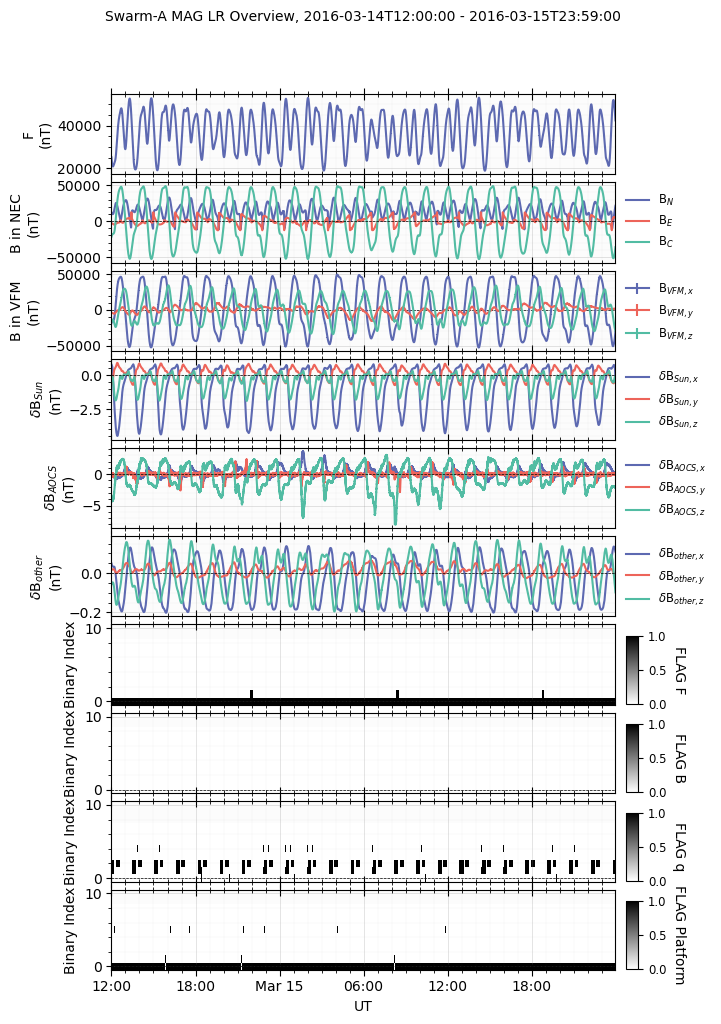

In [2]:
def test_swarm_MAG_LR_overview():
    """Test Swarm MAG LR data product
    
    """
    dt_fr = datetime.datetime(2016, 3, 14, 12, 0)
    dt_to = datetime.datetime(2016, 3, 15, 23, 59)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], sat_id='A', add_APEX=True,)

    panel_layouts = [
        [ds['F']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Overview'.format(ds.sat_id), fontsize='medium', append_time=True)

    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_overview'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_overview()

### Zoomed-in view with a short time span

Create a new figure: Figure(800x1200).
Searching the data product "MAG_LR" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_LR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.


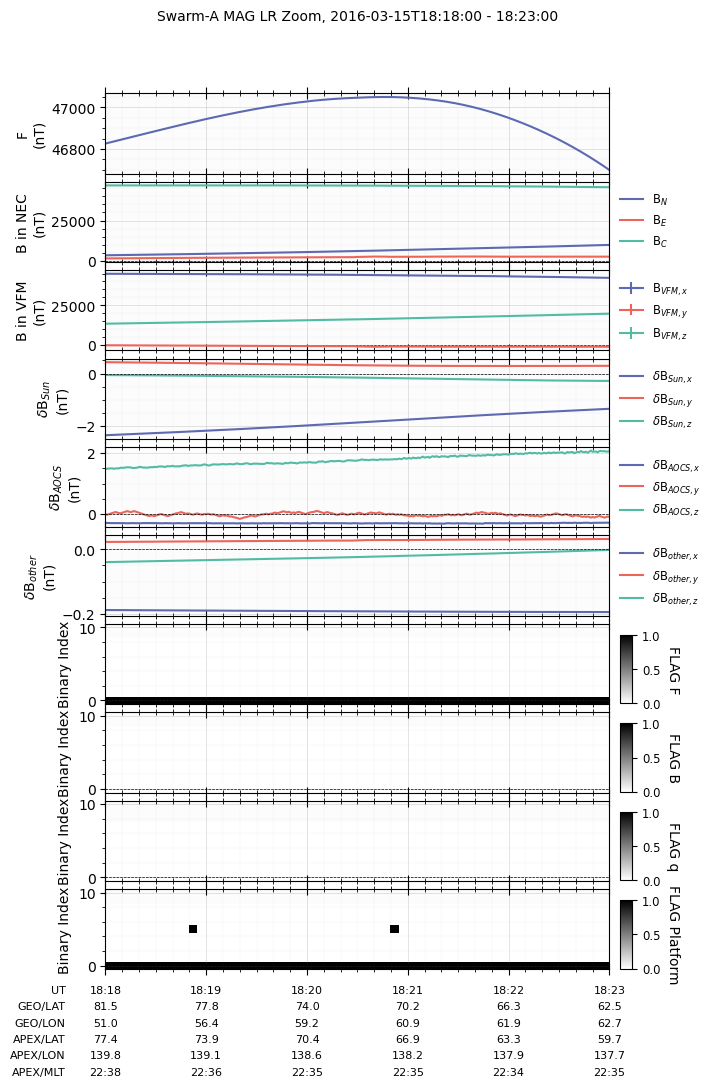

In [3]:
def test_swarm_MAG_LR_zoom():
    """Test Swarm MAG LR data product
    
    """
    dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
    dt_to = datetime.datetime(2016, 3, 15, 18, 23)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], sat_id='A', add_APEX=True,)

    panel_layouts = [
        [ds['F']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_zoom'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_zoom()

## Swarm MAG HR data

Create a new figure: Figure(800x1200).
Searching the data product "MAG_HR" with the version "latest" on the server...
INFO: Indexing the files for the product MAG_HR of the satellite A ...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_HR/0701/Sat_A/2016/SW_OPER_MAGA_HR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_HR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_HR/0701/Sat_A/2016/SW_OPER_MAGA_HR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.


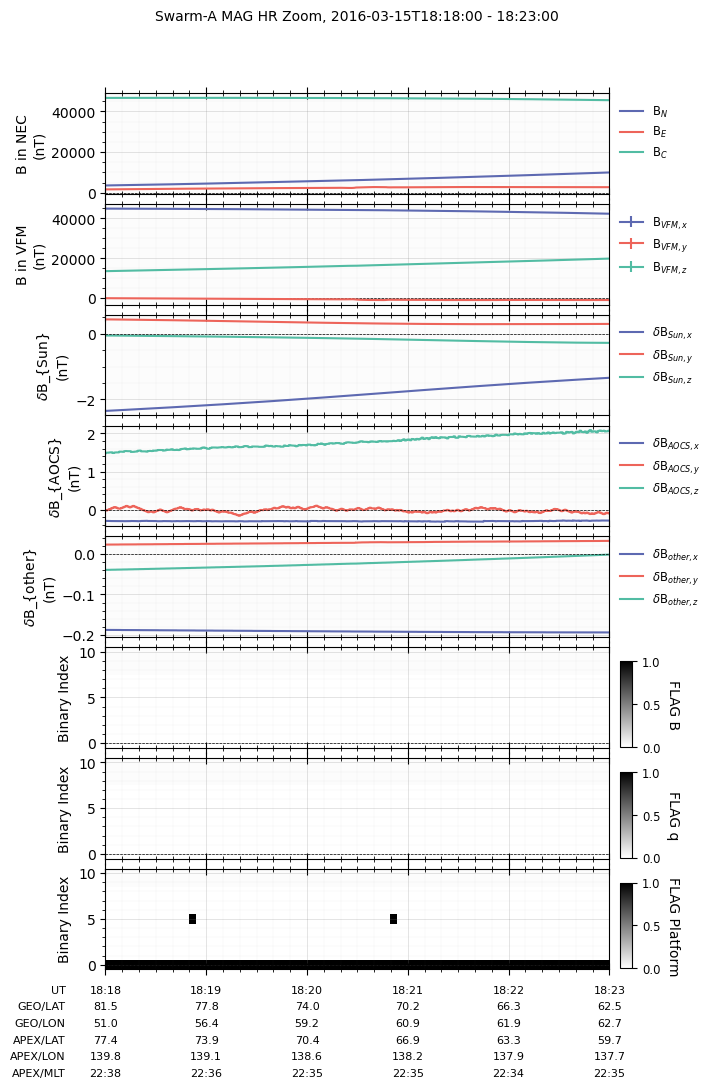

In [4]:
def test_swarm_MAG_HR_zoom():
    """Test Swarm MAG HR data product
    
    """
    dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
    dt_to = datetime.datetime(2016, 3, 15, 18, 23)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_hr'], sat_id='A', add_APEX=True,)

    panel_layouts = [
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG HR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_HR_Swarm-{}_zoom'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_HR_zoom()


## Swarm MAG LR data from Swarm VirES service

### With CHAOS modeled B-field

Create a new figure: Figure(800x1200).
INFO: Loading data from VirES for collection SW_OPER_MAGA_LR_1B with products {'measurements': ['B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error', 'q_NEC_CRF', 'Att_error', 'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F', 'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other'], 'models': ['CHAOS-Core'], 'residuals': False}.
Processing:  100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] (0.219MB)
INFO: Data loaded from VirES.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


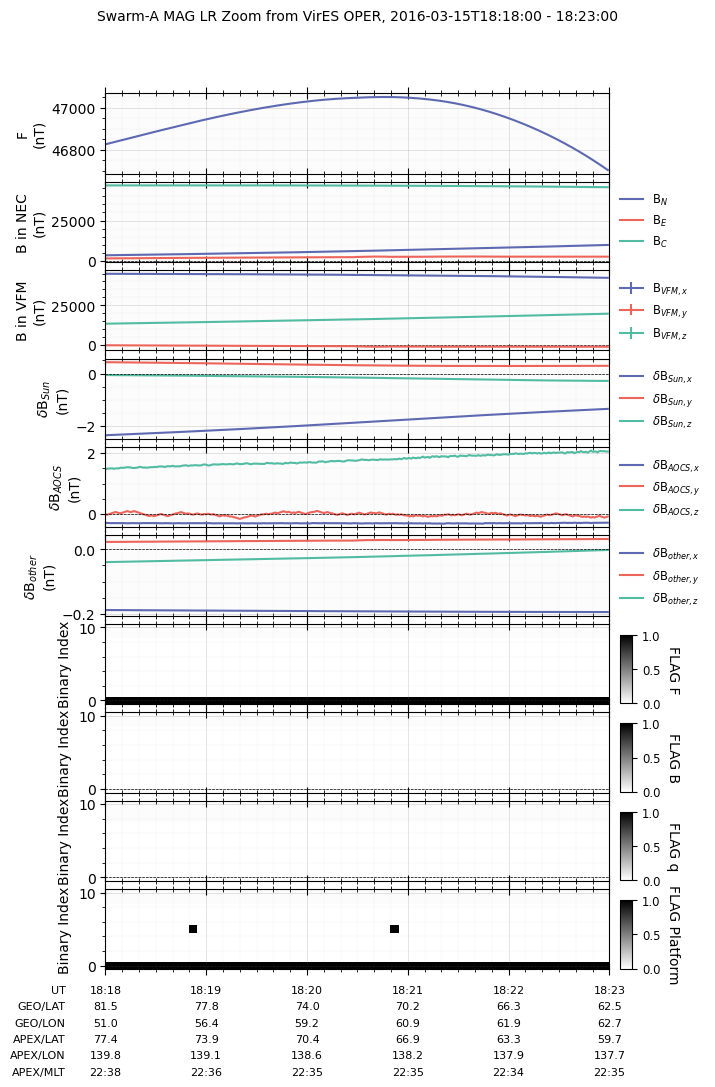

In [5]:
def test_swarm_MAG_LR_from_VirES_OPER():
    """Test loading Swarm MAG LR data product from VirES

    """
    dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
    dt_to = datetime.datetime(2016, 3, 15, 18, 23)

    # Default kwargs for VirES data loading, which can be overridden when calling the dock method to load data from VirES. The measurements, models, and residuals to load can be specified in the kwargs_products dictionary. The default settings are for loading all available measurements and models, and no residuals. The available measurements and models depend on the specific collection and product being loaded, and can be checked in the VirES API documentation or by inspecting the variables in the loaded dataset.
    kwargs_products_default = {
            "measurements": [
                'B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error',
                'q_NEC_CRF', 'Att_error',
                'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F',
                'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other',
            ],
            "models": [
                'CHAOS-Core',
            ],
            "residuals": False,
        }
    
    
    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
        from_VirES=True, from_FAST=False,
        sat_id='A', add_APEX=True,
        kwargs_VirES={"kwargs_products": kwargs_products_default},
    )

    panel_layouts = [
        [ds['F']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Zoom from VirES OPER'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_zoom_VirES_OPER'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_from_VirES_OPER()

### With CHAOS modeled B-field disturbances

Create a new figure: Figure(800x1200).
INFO: Loading data from VirES for collection SW_OPER_MAGA_LR_1B with products {'measurements': ['B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error', 'q_NEC_CRF', 'Att_error', 'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F', 'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other'], 'models': ['CHAOS-Core'], 'residuals': True}.
Processing:  100%|██████████|  [ Elapsed: 00:01, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] (0.202MB)
INFO: Data loaded from VirES.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


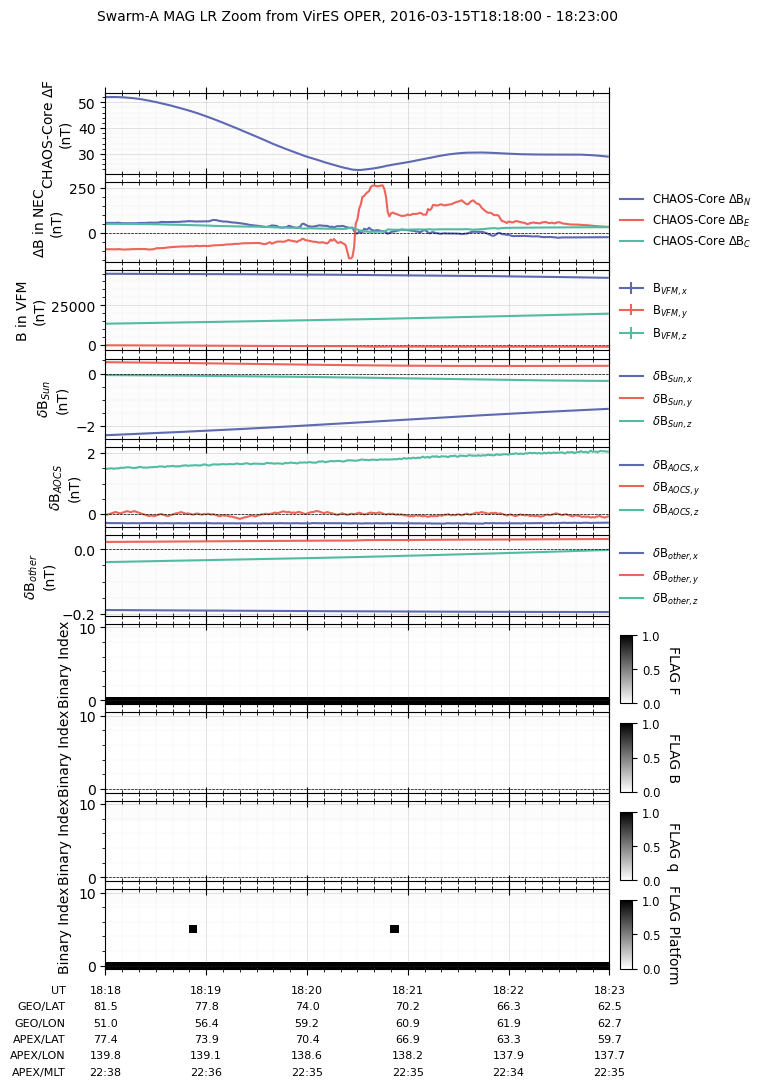

In [6]:
def test_swarm_MAG_LR_from_VirES_OPER_Residuals():
    """Test loading Swarm MAG LR data product from VirES

    """
    dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
    dt_to = datetime.datetime(2016, 3, 15, 18, 23)

    # Default kwargs for VirES data loading, which can be overridden when calling the dock method to load data from VirES. The measurements, models, and residuals to load can be specified in the kwargs_products dictionary. The default settings are for loading all available measurements and models, and no residuals. The available measurements and models depend on the specific collection and product being loaded, and can be checked in the VirES API documentation or by inspecting the variables in the loaded dataset.
    kwargs_products_default = {
            "measurements": [
                'B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error',
                'q_NEC_CRF', 'Att_error',
                'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F',
                'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other',
            ],
            "models": [
                'CHAOS-Core',
            ],
            "residuals": True,
        }
    
    
    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
        from_VirES=True, from_FAST=False,
        sat_id='A', add_APEX=True,
        kwargs_VirES={"kwargs_products": kwargs_products_default},
    )

    panel_layouts = [
        [ds['F_res_CHAOS-Core']],
        [ds['B_res_CHAOS-Core_N'], ds['B_res_CHAOS-Core_E'], ds['B_res_CHAOS-Core_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Zoom from VirES OPER'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_zoom_VirES_OPER_Residuals'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_from_VirES_OPER_Residuals()


### Swarm MAG LR FAST data from Swarm VirES service

Create a new figure: Figure(800x1200).
INFO: Loading data from VirES for collection SW_FAST_MAGA_LR_1B with products {'measurements': ['B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error', 'q_NEC_CRF', 'Att_error', 'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F', 'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other'], 'models': ['CHAOS-Core'], 'residuals': False}.
Processing:  100%|██████████|  [ Elapsed: 00:01, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] (0.344MB)
INFO: Data loaded from VirES.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


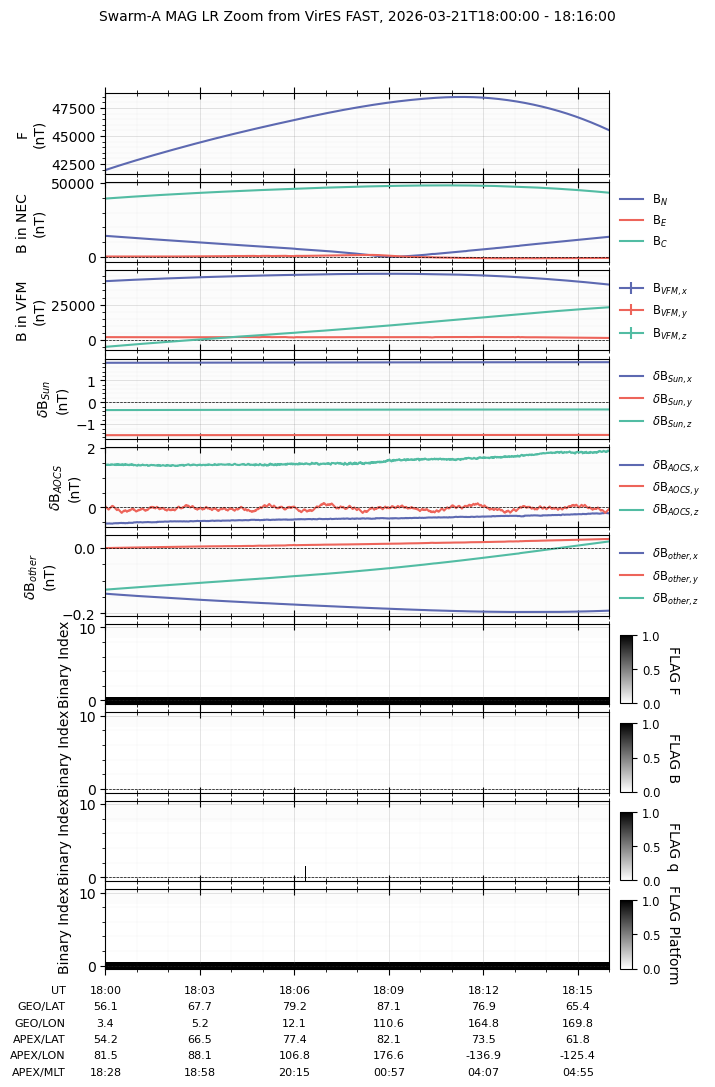

In [7]:
def test_swarm_MAG_LR_from_VirES_FAST():
    """Test loading Swarm MAG LR data product from VirES

    """
    dt_fr = datetime.datetime(2026, 3, 21, 18, 00)
    dt_to = datetime.datetime(2026, 3, 21, 18, 16)

    # Default kwargs for VirES data loading, which can be overridden when calling the dock method to load data from VirES. The measurements, models, and residuals to load can be specified in the kwargs_products dictionary. The default settings are for loading all available measurements and models, and no residuals. The available measurements and models depend on the specific collection and product being loaded, and can be checked in the VirES API documentation or by inspecting the variables in the loaded dataset.
    kwargs_products_default = {
            "measurements": [
                'B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error',
                'q_NEC_CRF', 'Att_error',
                'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F',
                'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other',
            ],
            "models": [
                'CHAOS-Core',
            ],
            "residuals": False,
        }
    
    
    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
        from_VirES=True, from_FAST=True,
        sat_id='A', add_APEX=True,
        kwargs_VirES={"kwargs_products": kwargs_products_default},
    )

    panel_layouts = [
        [ds['F']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Zoom from VirES FAST'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_zoom_VirES_FAST'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_from_VirES_FAST()


## Swarm MAG LR from VirES HAPI service

### With CHAOS modeled B-field disturbances

Create a new figure: Figure(800x1200).
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_OPER_MAGA_LR_1B, parameters Timestamp,Latitude,Longitude,Radius.
INFO: Data loaded from HAPI.
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_OPER_MAGA_LR_1B, parameters F,dF_Sun,dF_AOCS,dF_other,F_error,B_VFM,B_NEC,dB_Sun,dB_AOCS,dB_other,B_error.
INFO: Data loaded from HAPI.
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_OPER_MAGA_LR_1B, parameters q_NEC_CRF,Att_error,Flags_F,Flags_B,Flags_q,Flags_Platform,ASM_Freq_Dev.
INFO: Data loaded from HAPI.
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_OPER_MAGA_LR_1B, parameters SyncStatus,B_NEC_Model,F_Model,F_res_Model,B_NEC_res_Model.
INFO: Data loaded from HAPI.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_v

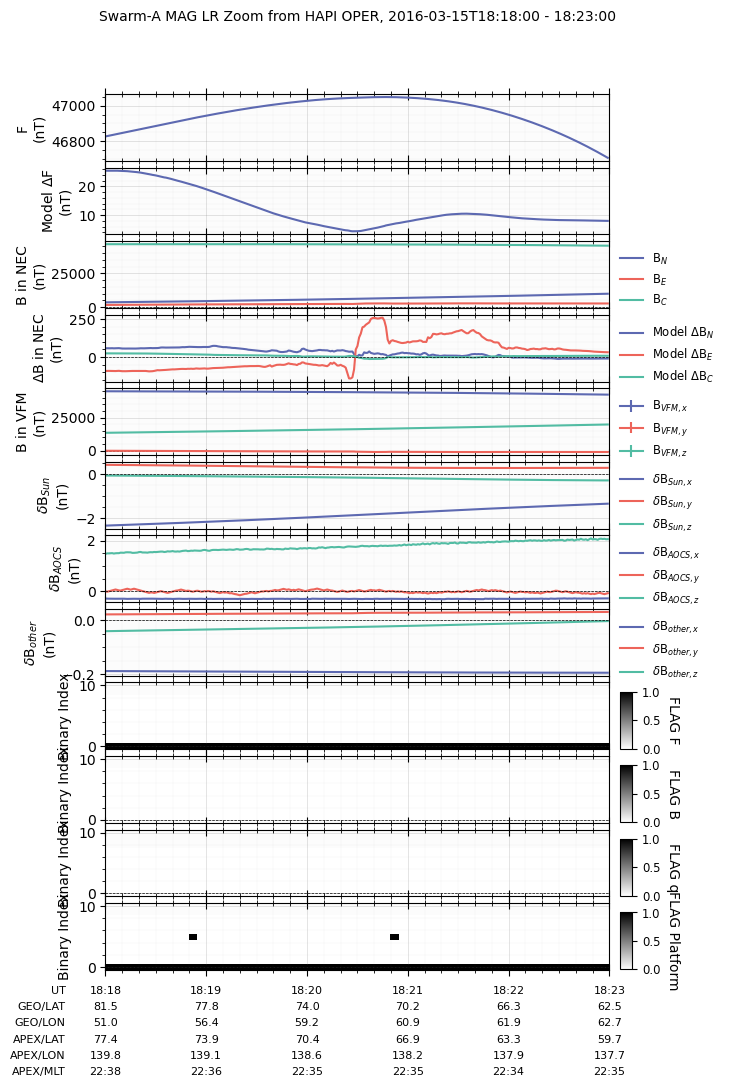

In [8]:
def test_swarm_MAG_LR_from_HAPI_OPER():
    """Test loading Swarm MAG LR data product from HAPI

    """
    dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
    dt_to = datetime.datetime(2016, 3, 15, 18, 23)    
    
    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
        from_HAPI=True, from_FAST=False,
        sat_id='A', add_APEX=True,
    )

    panel_layouts = [
        [ds['F']],
        [ds['F_res_Model']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_res_Model_N'], ds['B_res_Model_E'], ds['B_res_Model_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Zoom from HAPI OPER'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_zoom_HAPI_OPER'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_from_HAPI_OPER()

### Swarm MAG LR FAST from VirES HAPI service

Create a new figure: Figure(800x1200).
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_FAST_MAGA_LR_1B, parameters Timestamp,Latitude,Longitude,Radius.
INFO: Data loaded from HAPI.
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_FAST_MAGA_LR_1B, parameters F,dF_Sun,dF_AOCS,dF_other,F_error,B_VFM,B_NEC,dB_Sun,dB_AOCS,dB_other,B_error.
INFO: Data loaded from HAPI.
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_FAST_MAGA_LR_1B, parameters q_NEC_CRF,Att_error,Flags_F,Flags_B,Flags_q,Flags_Platform,ASM_Freq_Dev.
INFO: Data loaded from HAPI.
INFO: Loading data from HAPI for server https://vires.services/hapi, dataset SW_FAST_MAGA_LR_1B, parameters SyncStatus,B_NEC_Model,F_Model,F_res_Model,B_NEC_res_Model.
INFO: Data loaded from HAPI.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_v

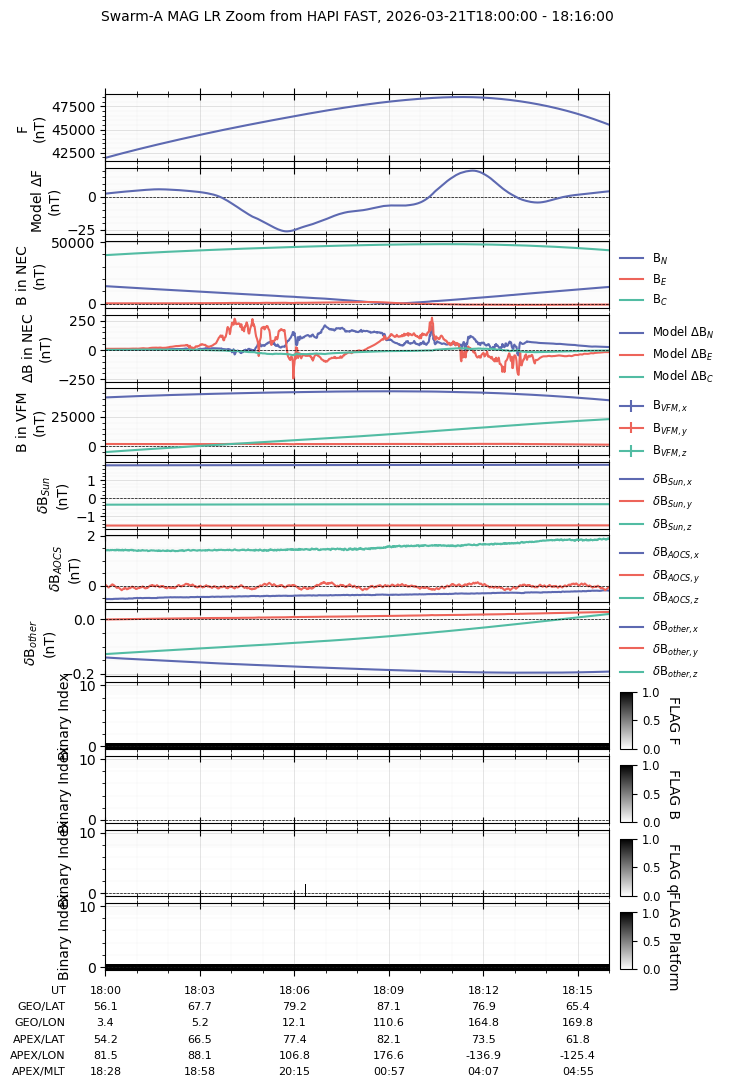

In [9]:
def test_swarm_MAG_LR_from_HAPI_FAST():
    """Test loading Swarm MAG LR data product from HAPI

    """
    dt_fr = datetime.datetime(2026, 3, 21, 18, 00)
    dt_to = datetime.datetime(2026, 3, 21, 18, 16)
    
    
    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 12)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]  # Not applicable for very scattered data points like AEJ_PBS peaks
        )

    ds = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
        from_HAPI=True, from_FAST=True,
        sat_id='A', add_APEX=True,
    )

    panel_layouts = [
        [ds['F']],
        [ds['F_res_Model']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_res_Model_N'], ds['B_res_Model_E'], ds['B_res_Model_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw()
    db.add_title(title='Swarm-{} MAG LR Zoom from HAPI FAST'.format(ds.sat_id), fontsize='medium', append_time=True)
    
    db.save_figure(
        file_dir=file_dir_figure, 
        file_name='example_MAG_LR_Swarm-{}_zoom_HAPI_FAST'.format(ds.sat_id), 
        dpi=100, 
        append_time=False
    )
    db.show()
test_swarm_MAG_LR_from_HAPI_FAST()